In [ ]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))
import paths


# GP Kernel Comparison Results

Reads the summary JSON produced by `GP_kernel_comparison_Kfolds_masked_10seeds.py`
and displays performance tables for each kernel.

**Aggregation logic** (matching the training script):
1. Average metrics over folds within each seed → per-seed mean
2. Report `mean ± std` across those per-seed means

In [1]:
import json
import glob
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

In [ ]:
# ── Configuration ─────────────────────────────────────────────────────────────
# Point this at the summary JSON written by the training script.
# If you have multiple summary files (e.g. from re-runs), set the path explicitly
# or let the cell below pick the most recent one automatically.

save_dir = str(paths.CV_RESULTS_DIR / "10seed_GP_kernelselect_raw") + "/"

# Auto-select the most recent summary file, or set manually:
# summary_path = "/path/to/GP_kernel_comparison_summary_2026-04-16_12-00-00.json"
candidates = sorted(glob.glob(os.path.join(save_dir, "GP_kernel_comparison_summary_*.json")))
if not candidates:
    raise FileNotFoundError(f"No summary JSON found in {save_dir}")
summary_path = candidates[-1]   # most recent
print("Loading:", summary_path)

In [3]:
# ── Load and flatten to a DataFrame ──────────────────────────────────────────

with open(summary_path) as f:
    raw = json.load(f)

rows = []
for kernel_name, fold_list in raw.items():
    for entry in fold_list:
        row = dict(entry)          # already flat: kernel, seed, fold, metric cols
        row['kernel'] = kernel_name
        rows.append(row)

df = pd.DataFrame(rows)
print(f"{len(df)} fold records   |   kernels: {sorted(df['kernel'].unique())}")
df.head(3)

400 fold records   |   kernels: ['Linear', 'Matern12', 'Matern32', 'Matern52', 'Matern52+Lin', 'RBF', 'RBF+Linear', 'RatQuad']


,kernel,seed,fold,PCP_train_r2_norm,PCP_train_rmse_norm,PCP_train_r2_phys,PCP_train_rmse_phys,PCP_train_r2_norm_raw,PCP_train_r2_phys_raw,TLWP_train_r2_norm,...,OSR_test_r2_phys,OSR_test_rmse_phys,OSR_test_r2_norm_raw,OSR_test_r2_phys_raw,OLR_test_r2_norm,OLR_test_rmse_norm,OLR_test_r2_phys,OLR_test_rmse_phys,OLR_test_r2_norm_raw,OLR_test_r2_phys_raw
0,RBF,0,0,0.845304,0.392005,0.845304,1.504142e-09,"[0.8472791910171509, 0.8549289703369141, 0.853...","[0.847279145801689, 0.854928974233138, 0.85349...",0.899831,...,0.580464,5.125454,"[0.7370648980140686, 0.6836961507797241, 0.619...","[0.7370648853707834, 0.6836961001863648, 0.619...",0.564919,0.485855,0.564919,3.086352,"[0.4892832040786743, 0.5311980843544006, 0.514...","[0.48928323668432894, 0.5311980717552292, 0.51..."
1,RBF,0,1,0.891610,0.328064,0.891610,1.155372e-09,"[0.8880438208580017, 0.8931260704994202, 0.891...","[0.8880437965466657, 0.8931260443069164, 0.891...",0.937510,...,0.020950,7.371910,"[0.3647218346595764, 0.2785193920135498, -0.00...","[0.36472179851989195, 0.27851945250130306, -0....",-0.350656,0.771952,-0.350656,4.218184,"[-0.23679745197296143, -0.34508442878723145, -...","[-0.2367974001476636, -0.3450845816687642, -0...."
2,RBF,0,2,0.864369,0.366881,0.864369,1.348222e-09,"[0.86130690574646, 0.866129994392395, 0.866748...","[0.8613068770910776, 0.8661299982818647, 0.866...",0.918983,...,0.262773,8.218047,"[0.5504859089851379, 0.4732987880706787, 0.308...","[0.550485908411486, 0.47329881293305476, 0.308...",0.139990,0.786268,0.139990,4.958950,"[0.010315954685211182, 0.14983469247817993, 0....","[0.010315938546700099, 0.1498348103580629, 0.2..."


In [4]:
# ── Aggregate: fold mean → seed mean → kernel mean ± std ──────────────────────

raw_cols    = [c for c in df.columns if c.endswith('_raw')]   # per-gridcell arrays, not scalar-aggregatable
metric_cols = [c for c in df.columns if c not in ('kernel', 'seed', 'fold') and c not in raw_cols]

# Step 1: average folds within each (kernel, seed)
per_seed = (
    df.groupby(['kernel', 'seed'])[metric_cols]
    .mean()
    .reset_index()
)

# Step 2: mean and std across seeds for each kernel
agg_mean = per_seed.groupby('kernel')[metric_cols].mean()
agg_std  = per_seed.groupby('kernel')[metric_cols].std(ddof=1)

# PCP RMSE (physical space) is many orders of magnitude smaller than the other
# variables — render those columns scaled to a fixed e-09 exponent so all rows
# stay directly comparable, rather than each value floating to its own exponent.
def fmt_for_col(col):
    if col.startswith('PCP') and 'rmse_phys' in col:
        return lambda v: f'{v * 1e9:.3f}e-09'
    return '{:.3f}'.format

# Combine into "mean (±std)" strings for display
agg_str = agg_mean.copy().astype(str)
for col in metric_cols:
    fmt = fmt_for_col(col)
    agg_str[col] = agg_mean[col].map(fmt) + ' (±' + agg_std[col].map(fmt) + ')'

print("Aggregation complete.")

Aggregation complete.


In [5]:
# ── Helper to build a tidy sub-table ─────────────────────────────────────────

KERNEL_ORDER = ['RBF', 'Matern12', 'Matern32', 'Matern52',
                'RatQuad', 'Linear', 'RBF+Linear', 'Matern52+Lin']

VARIABLES = ['PCP', 'TLWP', 'OSR', 'OLR']

def subtable(split, metric_suffix, title, add_avg=False):
    """Extract one metric (e.g. test R²_phys) for all variables and kernels.

    If add_avg, append an 'Average' column = mean across variables of the
    per-seed kernel means, with std = mean of the per-variable stds.
    """
    cols = [f'{v}_{split}_{metric_suffix}' for v in VARIABLES]
    missing = [c for c in cols if c not in agg_str.columns]
    if missing:
        print(f"Columns not found (skipping): {missing}")
        return
    tbl = agg_str[cols].copy()
    tbl.columns = VARIABLES
    if add_avg:
        avg_mean = agg_mean[cols].mean(axis=1)
        avg_std  = agg_std[cols].mean(axis=1)
        tbl['Average'] = avg_mean.map('{:.3f}'.format) + ' (±' + avg_std.map('{:.3f}'.format) + ')'
    # Reorder rows to match KERNEL_ORDER (only those present)
    order = [k for k in KERNEL_ORDER if k in tbl.index]
    tbl = tbl.loc[order]
    tbl.index.name = 'Kernel'
    print(f"\n{'─'*60}")
    print(f"  {title}")
    print(f"{'─'*60}")
    display(tbl.style.set_caption(title))
    return tbl

In [6]:
# ── Out-of-sample (test) tables ───────────────────────────────────────────────

tbl_r2_phys  = subtable('test', 'r2_phys',   'Test R²  (physical space)   mean ± std', add_avg=True)
tbl_r2_norm  = subtable('test', 'r2_norm',   'Test R²  (normalized space) mean ± std', add_avg=True)
tbl_rmse_phys = subtable('test', 'rmse_phys', 'Test RMSE (physical space)  mean ± std')
tbl_rmse_norm = subtable('test', 'rmse_norm', 'Test RMSE (normalized space) mean ± std')


────────────────────────────────────────────────────────────
  Test R²  (physical space)   mean ± std
────────────────────────────────────────────────────────────


,PCP,TLWP,OSR,OLR,Average
Kernel,,,,,
RBF,0.378 (±0.048),0.623 (±0.020),0.318 (±0.053),0.137 (±0.082),0.364 (±0.051)
Matern12,0.410 (±0.048),0.648 (±0.015),0.380 (±0.052),0.233 (±0.087),0.418 (±0.051)
Matern32,0.393 (±0.051),0.640 (±0.020),0.332 (±0.055),0.138 (±0.083),0.376 (±0.052)
Matern52,0.390 (±0.050),0.637 (±0.020),0.326 (±0.054),0.134 (±0.082),0.372 (±0.051)
RatQuad,0.389 (±0.051),0.639 (±0.020),0.325 (±0.055),0.127 (±0.083),0.370 (±0.052)
Linear,0.341 (±0.065),0.575 (±0.021),0.352 (±0.055),0.225 (±0.108),0.373 (±0.062)
RBF+Linear,0.396 (±0.051),0.648 (±0.020),0.352 (±0.054),0.158 (±0.074),0.389 (±0.050)
Matern52+Lin,0.400 (±0.051),0.650 (±0.019),0.355 (±0.054),0.165 (±0.075),0.393 (±0.050)



────────────────────────────────────────────────────────────
  Test R²  (normalized space) mean ± std
────────────────────────────────────────────────────────────


,PCP,TLWP,OSR,OLR,Average
Kernel,,,,,
RBF,0.378 (±0.048),0.623 (±0.020),0.318 (±0.053),0.137 (±0.082),0.364 (±0.051)
Matern12,0.410 (±0.048),0.648 (±0.015),0.380 (±0.052),0.233 (±0.087),0.418 (±0.051)
Matern32,0.393 (±0.051),0.640 (±0.020),0.332 (±0.055),0.138 (±0.083),0.376 (±0.052)
Matern52,0.390 (±0.050),0.637 (±0.020),0.326 (±0.054),0.134 (±0.082),0.372 (±0.051)
RatQuad,0.389 (±0.051),0.639 (±0.020),0.325 (±0.055),0.127 (±0.083),0.370 (±0.052)
Linear,0.341 (±0.065),0.575 (±0.021),0.352 (±0.055),0.225 (±0.108),0.373 (±0.062)
RBF+Linear,0.396 (±0.051),0.648 (±0.020),0.352 (±0.054),0.158 (±0.074),0.389 (±0.050)
Matern52+Lin,0.400 (±0.051),0.650 (±0.019),0.355 (±0.054),0.165 (±0.075),0.393 (±0.050)



────────────────────────────────────────────────────────────
  Test RMSE (physical space)  mean ± std
────────────────────────────────────────────────────────────


,PCP,TLWP,OSR,OLR
Kernel,,,,
RBF,2.653e-09 (±0.061e-09),0.012 (±0.000),7.539 (±0.278),4.834 (±0.200)
Matern12,2.594e-09 (±0.044e-09),0.012 (±0.000),7.251 (±0.220),4.637 (±0.157)
Matern32,2.613e-09 (±0.062e-09),0.012 (±0.000),7.460 (±0.275),4.830 (±0.192)
Matern52,2.623e-09 (±0.062e-09),0.012 (±0.000),7.490 (±0.279),4.837 (±0.197)
RatQuad,2.624e-09 (±0.062e-09),0.012 (±0.000),7.497 (±0.278),4.851 (±0.194)
Linear,2.703e-09 (±0.037e-09),0.012 (±0.000),7.391 (±0.140),4.594 (±0.092)
RBF+Linear,2.594e-09 (±0.056e-09),0.012 (±0.000),7.373 (±0.270),4.799 (±0.183)
Matern52+Lin,2.589e-09 (±0.055e-09),0.012 (±0.000),7.351 (±0.268),4.784 (±0.183)



────────────────────────────────────────────────────────────
  Test RMSE (normalized space) mean ± std
────────────────────────────────────────────────────────────


,PCP,TLWP,OSR,OLR
Kernel,,,,
RBF,0.750 (±0.015),0.594 (±0.014),0.787 (±0.023),0.852 (±0.023)
Matern12,0.732 (±0.010),0.574 (±0.011),0.757 (±0.017),0.820 (±0.017)
Matern32,0.738 (±0.015),0.579 (±0.014),0.778 (±0.022),0.849 (±0.022)
Matern52,0.741 (±0.015),0.582 (±0.015),0.782 (±0.023),0.851 (±0.023)
RatQuad,0.740 (±0.015),0.580 (±0.015),0.782 (±0.022),0.853 (±0.023)
Linear,0.768 (±0.009),0.628 (±0.012),0.766 (±0.014),0.814 (±0.018)
RBF+Linear,0.734 (±0.013),0.572 (±0.014),0.767 (±0.022),0.841 (±0.022)
Matern52+Lin,0.733 (±0.013),0.571 (±0.014),0.765 (±0.022),0.839 (±0.021)


In [7]:
# ── In-sample (train) tables — useful for diagnosing overfitting ──────────────

tbl_train_r2   = subtable('train', 'r2_phys',   'Train R²  (physical space)  mean ± std', add_avg=True)
tbl_train_rmse = subtable('train', 'rmse_phys', 'Train RMSE (physical space) mean ± std')


────────────────────────────────────────────────────────────
  Train R²  (physical space)  mean ± std
────────────────────────────────────────────────────────────


,PCP,TLWP,OSR,OLR,Average
Kernel,,,,,
RBF,0.890 (±0.010),0.933 (±0.006),0.887 (±0.010),0.871 (±0.010),0.895 (±0.009)
Matern12,1.000 (±0.000),1.000 (±0.000),1.000 (±0.000),1.000 (±0.000),1.000 (±0.000)
Matern32,0.977 (±0.006),0.986 (±0.003),0.975 (±0.006),0.971 (±0.007),0.977 (±0.005)
Matern52,0.946 (±0.008),0.967 (±0.005),0.944 (±0.009),0.935 (±0.009),0.948 (±0.008)
RatQuad,0.949 (±0.011),0.969 (±0.006),0.947 (±0.011),0.939 (±0.012),0.951 (±0.010)
Linear,0.531 (±0.002),0.694 (±0.002),0.545 (±0.003),0.496 (±0.003),0.566 (±0.002)
RBF+Linear,0.983 (±0.007),0.990 (±0.004),0.982 (±0.007),0.979 (±0.008),0.983 (±0.006)
Matern52+Lin,0.997 (±0.002),0.998 (±0.001),0.997 (±0.002),0.996 (±0.003),0.997 (±0.002)



────────────────────────────────────────────────────────────
  Train RMSE (physical space) mean ± std
────────────────────────────────────────────────────────────


,PCP,TLWP,OSR,OLR
Kernel,,,,
RBF,1.171e-09 (±0.058e-09),0.005 (±0.000),3.231 (±0.155),2.137 (±0.092)
Matern12,0.000e-09 (±0.000e-09),0.000 (±0.000),0.000 (±0.000),0.000 (±0.000)
Matern32,0.475e-09 (±0.077e-09),0.002 (±0.000),1.317 (±0.207),0.884 (±0.130)
Matern52,0.794e-09 (±0.071e-09),0.003 (±0.000),2.196 (±0.192),1.466 (±0.118)
RatQuad,0.739e-09 (±0.103e-09),0.003 (±0.000),2.048 (±0.279),1.373 (±0.174)
Linear,2.447e-09 (±0.005e-09),0.011 (±0.000),6.688 (±0.024),4.346 (±0.021)
RBF+Linear,0.397e-09 (±0.092e-09),0.002 (±0.000),1.103 (±0.250),0.754 (±0.167)
Matern52+Lin,0.106e-09 (±0.061e-09),0.000 (±0.000),0.292 (±0.163),0.199 (±0.109)


In [8]:
# ── Mean R² across all variables (single ranking column) ─────────────────────
# Uses physical-space test R² values for a quick one-number ranking.

r2_cols = [f'{v}_test_r2_phys' for v in VARIABLES]
r2_cols_present = [c for c in r2_cols if c in agg_mean.columns]

ranking = pd.DataFrame({
    'Mean test R² (phys)': agg_mean[r2_cols_present].mean(axis=1),
    'Std  test R² (phys)': agg_std[r2_cols_present].mean(axis=1),   # avg of per-var stds
})
order = [k for k in KERNEL_ORDER if k in ranking.index]
ranking = ranking.loc[order].sort_values('Mean test R² (phys)', ascending=False)
ranking.index.name = 'Kernel'

print("\n" + "─"*50)
print("  Kernel ranking by mean test R² (physical, all variables)")
print("─"*50)
display(
    ranking.style
    .format({'Mean test R² (phys)': '{:.3f}', 'Std  test R² (phys)': '{:.3f}'})
    .background_gradient(subset=['Mean test R² (phys)'], cmap='YlGn')
    .set_caption('Kernel ranking — higher is better')
)


──────────────────────────────────────────────────
  Kernel ranking by mean test R² (physical, all variables)
──────────────────────────────────────────────────


,Mean test R² (phys),Std test R² (phys)
Kernel,,
Matern12,0.418,0.051
Matern52+Lin,0.393,0.050
RBF+Linear,0.389,0.050
Matern32,0.376,0.052
Linear,0.373,0.062
Matern52,0.372,0.051
RatQuad,0.370,0.052
RBF,0.364,0.051


In [9]:
# ── LaTeX export ───────────────────────────────────────────────────────────────
# Converts a "mean ± std" table (as produced by subtable()) into a LaTeX
# tabular you can paste directly into a .tex file.

def to_latex_table(tbl, caption, label):
    """Print a LaTeX table for a DataFrame of 'mean ± std' strings."""
    tbl_tex = tbl.copy()
    tbl_tex.columns = [c.replace('²', '$^2$') for c in tbl_tex.columns]
    tbl_tex.index.name = 'Kernel'
    # '±' -> '$\pm$' for proper LaTeX math rendering
    for col in tbl_tex.columns:
        tbl_tex[col] = tbl_tex[col].astype(str).str.replace('±', r'$\pm$', regex=False)

    latex_str = tbl_tex.to_latex(
        column_format='l' + 'c' * tbl_tex.shape[1],
        caption=caption.replace('²', '$^2$'),
        label=label,
        escape=False,
    )
    print(latex_str)
    return latex_str

# Test R² (physical space) — the table most people want for a paper/report
latex_r2_phys = to_latex_table(
    tbl_r2_phys,
    caption='Test $R^2$ (physical space), mean $\\pm$ std across 10 seeds',
    label='tab:gp_kernel_r2_phys',
)

\begin{table}
\caption{Test $R^2$ (physical space), mean $\pm$ std across 10 seeds}
\label{tab:gp_kernel_r2_phys}
\begin{tabular}{lccccc}
\toprule
 & PCP & TLWP & OSR & OLR & Average \\
Kernel &  &  &  &  &  \\
\midrule
RBF & 0.378 ($\pm$0.048) & 0.623 ($\pm$0.020) & 0.318 ($\pm$0.053) & 0.137 ($\pm$0.082) & 0.364 ($\pm$0.051) \\
Matern12 & 0.410 ($\pm$0.048) & 0.648 ($\pm$0.015) & 0.380 ($\pm$0.052) & 0.233 ($\pm$0.087) & 0.418 ($\pm$0.051) \\
Matern32 & 0.393 ($\pm$0.051) & 0.640 ($\pm$0.020) & 0.332 ($\pm$0.055) & 0.138 ($\pm$0.083) & 0.376 ($\pm$0.052) \\
Matern52 & 0.390 ($\pm$0.050) & 0.637 ($\pm$0.020) & 0.326 ($\pm$0.054) & 0.134 ($\pm$0.082) & 0.372 ($\pm$0.051) \\
RatQuad & 0.389 ($\pm$0.051) & 0.639 ($\pm$0.020) & 0.325 ($\pm$0.055) & 0.127 ($\pm$0.083) & 0.370 ($\pm$0.052) \\
Linear & 0.341 ($\pm$0.065) & 0.575 ($\pm$0.021) & 0.352 ($\pm$0.055) & 0.225 ($\pm$0.108) & 0.373 ($\pm$0.062) \\
RBF+Linear & 0.396 ($\pm$0.051) & 0.648 ($\pm$0.020) & 0.352 ($\pm$0.054) & 0.158 ($\p

In [10]:
# Test RMSE (physical space)
latex_rmse_phys = to_latex_table(
    tbl_rmse_phys,
    caption='Test RMSE (physical space), mean $\\pm$ std across 10 seeds',
    label='tab:gp_kernel_rmse_phys',
)

\begin{table}
\caption{Test RMSE (physical space), mean $\pm$ std across 10 seeds}
\label{tab:gp_kernel_rmse_phys}
\begin{tabular}{lcccc}
\toprule
 & PCP & TLWP & OSR & OLR \\
Kernel &  &  &  &  \\
\midrule
RBF & 2.653e-09 ($\pm$0.061e-09) & 0.012 ($\pm$0.000) & 7.539 ($\pm$0.278) & 4.834 ($\pm$0.200) \\
Matern12 & 2.594e-09 ($\pm$0.044e-09) & 0.012 ($\pm$0.000) & 7.251 ($\pm$0.220) & 4.637 ($\pm$0.157) \\
Matern32 & 2.613e-09 ($\pm$0.062e-09) & 0.012 ($\pm$0.000) & 7.460 ($\pm$0.275) & 4.830 ($\pm$0.192) \\
Matern52 & 2.623e-09 ($\pm$0.062e-09) & 0.012 ($\pm$0.000) & 7.490 ($\pm$0.279) & 4.837 ($\pm$0.197) \\
RatQuad & 2.624e-09 ($\pm$0.062e-09) & 0.012 ($\pm$0.000) & 7.497 ($\pm$0.278) & 4.851 ($\pm$0.194) \\
Linear & 2.703e-09 ($\pm$0.037e-09) & 0.012 ($\pm$0.000) & 7.391 ($\pm$0.140) & 4.594 ($\pm$0.092) \\
RBF+Linear & 2.594e-09 ($\pm$0.056e-09) & 0.012 ($\pm$0.000) & 7.373 ($\pm$0.270) & 4.799 ($\pm$0.183) \\
Matern52+Lin & 2.589e-09 ($\pm$0.055e-09) & 0.012 ($\pm$0.000) & 7.351 

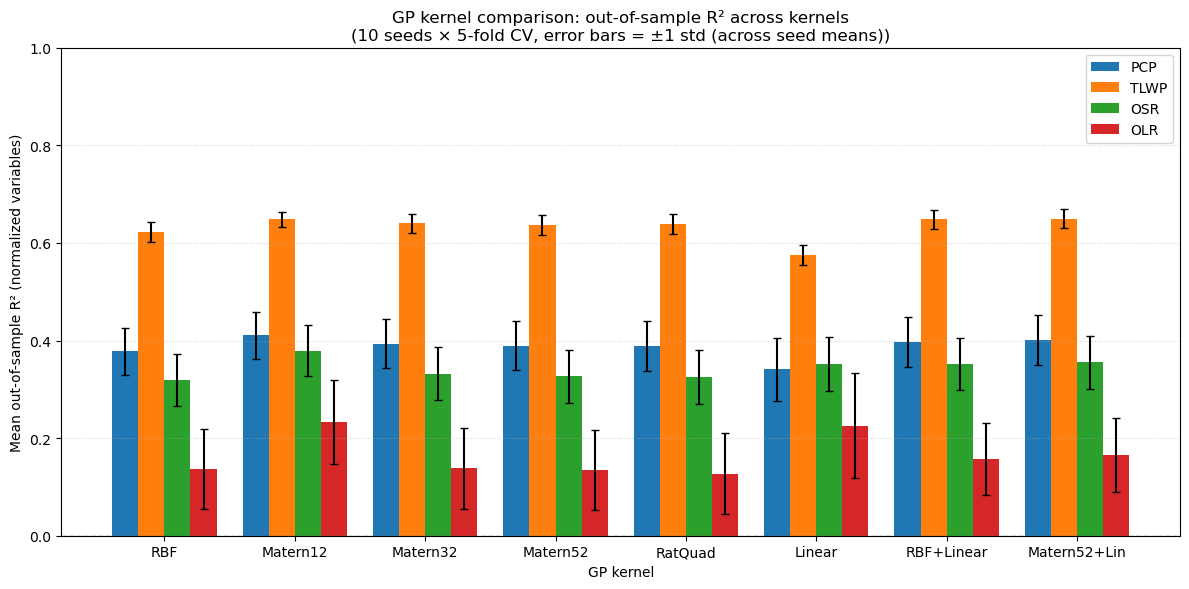

In [12]:
# ── Bar chart: out-of-sample R² across kernels, grouped by variable ───────────
# Mirrors the spline-regression comparison plot: one group of bars per kernel,
# one bar per variable within the group, error bars = ±1 std across seed means.

split, metric_suffix = 'test', 'r2_norm'
cols = [f'{v}_{split}_{metric_suffix}' for v in VARIABLES]

kernel_order = [k for k in KERNEL_ORDER if k in agg_mean.index]
means = agg_mean.loc[kernel_order, cols]
stds  = agg_std.loc[kernel_order, cols]

n_kernels = len(kernel_order)
n_vars    = len(VARIABLES)
x         = np.arange(n_kernels)
width     = 0.8 / n_vars

fig, ax = plt.subplots(figsize=(12, 6))
for i, (vname, col) in enumerate(zip(VARIABLES, cols)):
    offset = (i - (n_vars - 1) / 2) * width
    ax.bar(
        x + offset, means[col], width,
        yerr=stds[col], capsize=3, label=vname,
    )

ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(kernel_order, rotation=0)
ax.set_ylim(0, 1.0)
ax.set_xlabel('GP kernel')
ax.set_ylabel('Mean out-of-sample R² (normalized variables)')
ax.set_title(
    'GP kernel comparison: out-of-sample R² across kernels\n'
    '(10 seeds × 5-fold CV, error bars = ±1 std (across seed means))'
)
ax.legend()
ax.grid(axis='y', linestyle=':', alpha=0.5)
fig.tight_layout()
plt.show()